# Quantum logic gates with Rydberg atoms

Mariona Montaner Carbó


---------------------

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

-----

## Estructura atòmica del $^{87}Rb$ [1]

El Rubidi és un àtom alcalí amb configuració electrònica de l'estat fonamental $^{87} Rb$: $1s^2 2s^2 2p^6 3s^2 3p^6 3d^{10} 4s^2 4p^6 5s^1$


L'electró de valència es troba a l'orbital $5s$ i dona la major part de les propietats atòmiques ja que la restà d'electrons s'acoblen a moment angular total $J=0$.  A l'orbital $s$ l'electró té un moment angular orbital $L=0$ i per tant un moment angular total $J=0 \otimes 1/2 =1/2$. De manera que l'estat fonamental del $^{87}Rb$ és el nivell d'estructura fina $5^2S_{1/2}$.


#### Estructura grossa

Pels orbitals $s$ les funcions d'ona tenen una component significativa per $r$ petit i per tant penetren més en el nucli i "veuen" més càrrega nuclear. Així doncs, els electrons interns apantallen la càrrega nuclear i s'ha de considerar una càrrega efectiva. Els nivells d'energia no només dependran de $n$ sinò que també ho faran de $l$ a partir del defecte quàntic $\delta_l$ segons la fòrmula de Bohr modificada:

$$E(n,l)= -\frac{1}{2(n-\delta_l)^2}E_h $$

amb $E_h=27.211 $ eV i per l'orbital $s$ del $^{87}Rb$ , $\delta_l=3.19$ [1]



In [19]:
# Càlcul de l'energia de l'estructura grossa


def estructura_grossa(n):
    Eh=27.211386245988
    delta_l=3.19
    energia_grossa=-Eh/(2*(n-delta_l)**2)
    return energia_grossa
    
n=float(input('Energia estructura grossa (eV) n='))
estructura_grossa(n)

Energia estructura grossa (eV) n= 5


-4.153015208019902

#### Estructura fina


Degut a que l'estat fonamental del $^{87} Rb$ té un moment angular orbital $L=0$ no tenim correcció de l'energia degut al terme spin-òrbita i per tant, no hi ha desdoblament d'estructura fina. Pel que fa els termes de Darwin i la correcció de massa relativista tampoc canvien el valor del nivell d'energia de l'estructura grossa ja que el defecte quàntic $\delta_l$ és un valor expermiental i, per tant, ja es consideren aquestes correccions.

#### Estructura hiperfina


L'estrucura hiperfina també considera el moment angular total del nucli $I$, que per el $^{87}Rb$ és $I=3/2$.

El moment angular total $\vec{F}=\vec{J}+\vec{I}$ de l'estat fonamental serà doncs $F=1/2 \otimes 3/2 = 1 \oplus 2$ de manera que l'estat fonamental es desdoblarà en dos nivells hiperfins amb $F=1$ i $F=2$.

La correcció dels nivells d'estructura fina vindrà donada per:

$$\langle \mathcal{H}_{hf} \rangle = A \langle \vec{I}\cdot \vec{J}\rangle=\frac{A}{2} \langle \vec{F}^2-\vec{I}^2-\vec{J}^2\rangle$$

on $A$ és la constant de dipol magnètic que per el Rubidi té un valor $A=3.4173413$ GHz [2]. Aquest Hamiltonià serà diagonal en la base acoblada $\ket{I\,J\,F\, M_F}$ i per tant:

$$\langle \mathcal{H}_{hf} \rangle  = \frac{A}{2}[F(F+1)- I(I+1) - J(J-1)]\hbar^2$$ 

Per l'àtom de de $^{87} Rb$ aquests desplaçaments d'energia respecte el nivell d'estructura fina seran:

- $F=1$ $\rightarrow$ $\langle \mathcal{H}_{hf} \rangle^{F=1} = -\frac{5}{4}A$
  
- $F=2$ $\rightarrow$ $\langle \mathcal{H}_{hf} \rangle^{F=2} = \frac{3}{4}A$ 


La separació entre els dos nivells serà $\Delta E = 2A \approx 6.845$ GHz.


In [20]:
#Càlcul dels nous nivells hiperfins

def estructura_hiperfina(n,F, I, J):
    
    A=1.413*10**(-5) #eV
    energia_grossa=estructura_grossa(n)
    
    energia_hf=energia_grossa+(A/2.0)*(F*(F+1)-I*(I+1)-J*(J+1))

    return energia_hf


estructura_hiperfina(5,2,1.5,0.5)




-4.153004610519901

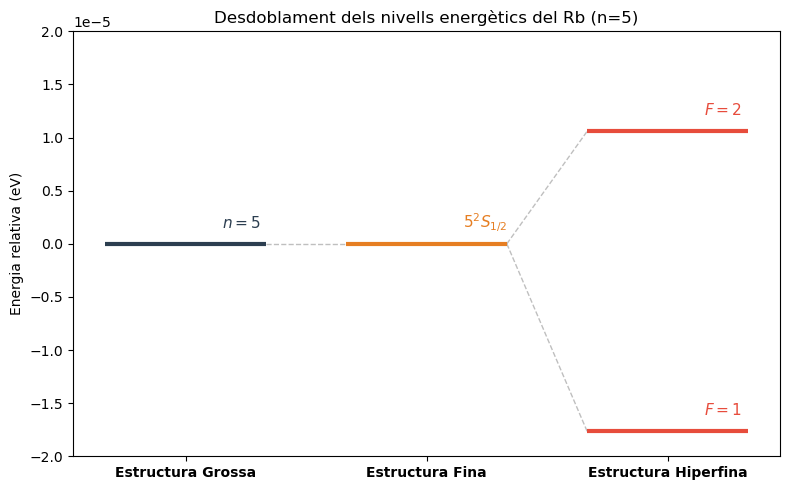

In [21]:
#Representació esquemàtica desdoblament dels nivells

def plot_desdoblament_nivells():
    fig, ax = plt.subplots(figsize=(8, 5))

    # Estructura Grossa: n=5
    n = 5
    E0 = estructura_grossa(n)

   # Estructura Hiperfina: desdoblament amb F=1 i F=2
    E_hf_1 = estructura_hiperfina(5,1, 1.5, 0.5)
    E_hf_2 = estructura_hiperfina(5,2, 1.5, 0.5)

    # Energies relatives
    grossa = [(0, r'$n=5$')]
    fina = [(0, r'$5^2S_{1/2}$')] #Estructura fina: no hi ha desdoblament ja que L=0
    hiperfina = [
        (E_hf_1 - E0, r'$F=1$'),
        (E_hf_2 - E0, r'$F=2$')
    ]

    nivells = [grossa, fina, hiperfina]
    nivells_columna = ['Estructura Grossa', 'Estructura Fina', 'Estructura Hiperfina']
    colors = ['#2c3e50', '#e67e22', '#e74c3c']

    
    for i, level_group in enumerate(nivells):
        x_start = i * 3
        x_end = x_start + 2

        for energy, txt in level_group:
            ax.hlines(energy, x_start, x_end, colors=colors[i], lw=3)
            ax.text(x_end - 0.55, energy+2e-6, txt,
                    va='center', fontsize=11,
                    fontweight='bold', color=colors[i])


    # Línies de connexió 
        if i > 0:
            x_prev_end = (i - 1) * 3 + 2
            x_curr_start = x_start
            
            # Connectem cada nivell de la columna actual amb el de l'anterior
            for energy_actual, _ in level_group:
                energy_previa = nivells[i-1][0][0]
                
                ax.plot([x_prev_end, x_curr_start], [energy_previa, energy_actual],
                        color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=1)
        
    
    ax.set_title('Desdoblament dels nivells energètics del Rb (n=5)')
    ax.set_ylabel('Energia relativa (eV)')

    ax.set_xticks([1, 4, 7])
    ax.set_xticklabels(nivells_columna, fontweight='bold')

   
    ax.set_ylim(-2e-5, 2e-5)

    plt.tight_layout()
    plt.show()
    
plot_desdoblament_nivells()

### Interacció amb camps magnètics: Efecte Zeeman anòmal

L'efecte Zeeman anòmal produeix el desdoblament dels nivells hiperfins en el règim de camp feble $\mu_B B \ll A$.

Per $A/2\approx 6.835$ GHz obtenim que el camp magnètic, per tal que ens trobem en aquest règim, ha de ser $B \ll 0.9$ T. 

Considerem un camp magnètic constant que apunta en la direcció $\hat{z}$:  $\vec{B}=B\hat{z}$

En aquest règim el Hamiltonià de la pertorbació dels nivells degut al camp és:

$$\mathcal{H}=g_F \mu_B \vec{F}\cdot \vec{B}=g_F\mu_B B F_z$$

$$g_F=\frac{F(F+1)+J(J+1)-I(I+1)}{2F(F+1)}g_J$$

amb $g_J \approx 2$.

Aquest Hamiltonià és diagonal en la base acoblada $\ket{I\,J\,F\, M_F}$ i per tant, la correcció d'energia dels nivells Zeeman vindà donada per:

$$E=g_F \mu_B B M_F$$

on $M_F=-F,...,F$.

Per tant, el nivell d'estructura hiperfina $F=1$ es desdoblarà en tres subnivells Zeeman corresponents a $M_F=-1,0,1$ amb $g_F=-1/2$ i el nivell $F=2$ es desdoblarà en cinc subnivells corresponents a $M_F=-2,-1,0,1,2$  amb $g_F=1/2$.

In [22]:
# Càlcul nivells energia Zeeman

def nivells_Zeeman(n,F,Mf,gF,B):

    mu_B=5.7883818060e-5 #eV/T
    energia_hf=estructura_hiperfina(n,F,1.5,0.5)

    energia_zeeman=energia_hf+gF*mu_B*B*Mf

    return energia_zeeman
    
B= 0.02
nivells_Zeeman(5,1,-1,-1/2,B)    

-4.153032291681721

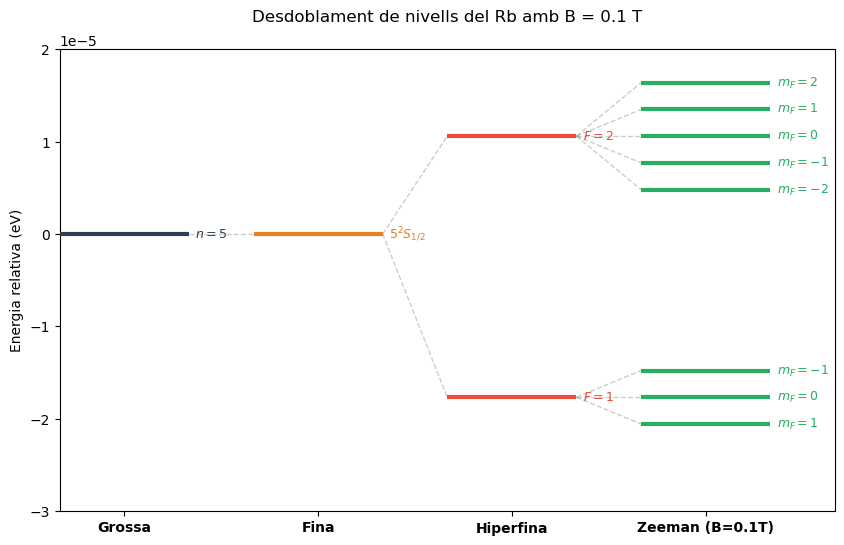

In [23]:
#Representació esquemàtica desdoblament dels nivells amb efecte Zeeman

def plot_desdoblament_zeeman(B):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 6))

    
    # Estructura Grossa: n=5 (mateixa energia que per estructura fina)
    n = 5
    E0 = estructura_grossa(n)

   # Estructura Hiperfina: desdoblament amb F=1 i F=2
    E_hf_1 = estructura_hiperfina(5,1, 1.5, 0.5)
    E_hf_2 = estructura_hiperfina(5,2, 1.5, 0.5)
    
    # Constants gF 
    gF_F1 = -0.5
    gF_F2 = 0.5

     # Energies relatives
    grossa = [(0, r'$n=5$')]
    fina = [(0, r'$5^2S_{1/2}$')] #Estructura fina: no hi ha desdoblament ja que L=0
    hiperfina = [
        (E_hf_1 - E0, r'$F=1$'),
        (E_hf_2 - E0, r'$F=2$')
    ]
    
    # Càlcul Zeeman per a cada mF
    zeeman_F1 = [(nivells_Zeeman(5, 1, mf, gF_F1, B) -E0, f'$m_F={mf}$') for mf in [-1, 0, 1]]
    zeeman_F2 = [(nivells_Zeeman(5, 2, mf, gF_F2, B) -E0, f'$m_F={mf}$') for mf in [-2, -1, 0, 1, 2]]
    
    nivells = [grossa, fina, hiperfina, zeeman_F1 + zeeman_F2]
    nivells_columna = ['Grossa', 'Fina', 'Hiperfina', f'Zeeman (B={B}T)']
    colors = ['#2c3e50', '#e67e22', '#e74c3c', '#27ae60']

    #nivells
    for i, level_group in enumerate(nivells):
        x_start = i * 3
        x_end = x_start + 2

        for energy, txt in level_group:
            ax.hlines(energy, x_start, x_end, colors=colors[i], lw=3, zorder=3)
            ax.text(x_end + 0.1, energy, txt, va='center', fontsize=9, fontweight='bold', color=colors[i])

        # linees de connexió
        if i > 0:
            x_prev_end = (i - 1) * 3 + 2
            x_curr_start = x_start
            
            for energy_actual, _ in level_group:
                
                if i == 3:  # Connexió Hiperfina -> Zeeman
            
                    dist_F1 = abs(energy_actual - (E_hf_1 - E0))
                    dist_F2 = abs(energy_actual - (E_hf_2 - E0))
                
                    energy_previa = (E_hf_1 - E0) if dist_F1 < dist_F2 else (E_hf_2 - E0)
                else:
                    # Connexió Grossa->Fina i Fina->Hiperfina
                    energy_previa = nivells[i-1][0][0]
                
                ax.plot([x_prev_end, x_curr_start], [energy_previa, energy_actual],
                        color='gray', linestyle='--', alpha=0.4, linewidth=1, zorder=1)

  
    ax.set_title(f'Desdoblament de nivells del Rb amb B = {B} T', pad=20)
    ax.set_ylabel('Energia relativa (eV)')
    ax.set_xticks([1, 4, 7, 10])
    ax.set_xticklabels(nivells_columna, fontweight='bold')
    
    
    ax.set_ylim(-3e-5, 2e-5)
    ax.set_xlim(0,12)

    
    plt.show()
    
plot_desdoblament_zeeman(B=0.1)

----

## Oscil·lacions de Rabi en un sistema a dos nivells [1]


Considerem un Hamiltonià del tipus:

$$\mathcal{H}=\mathcal{H}_0+\mathcal{H}_I(t)$$

on $\mathcal{H}_0$ descriu els nivells energètics de l'àtom sense pertorbar i $\mathcal{H}_I(t)$ representa la interacció amb un camp elèctric que pertorba els estats propis de $\mathcal{H}_0$. Per un àtom a dos nivells aquests estats propis tenen valors propis $E_1$ i $E_2$:

$$\mathcal{H}_0 \phi_1(\vec{r})=E_1\phi_1(\vec{r})$$
$$\mathcal{H}_0 \phi_2(\vec{r})=E_1\phi_2(\vec{r})$$

Si considerem el Hamiltonià sencer, la funció d'ona en qualsevol instant de temps es podrà escriure com:

$$\Psi (\vec{r},t)=c_1(t)\phi_1(\vec{r})e^{-iE_1 t/\hbar}+c_2(t)\phi_2(\vec{r})e^{-iE_2 t/\hbar}$$

Simplificant la notació $\omega_1\equiv E_1/\hbar$, $\omega_2\equiv E_2/\hbar$ i $\\ket{1}\equiv \phi_1(\vec{r],t)$ . $\\ket{2}\equiv \phi_2(\vec{r],t)$:

$$\Psi (\vec{r},t)=c_1(t)\ket{1}e^{-i\omega_1 t}+c_2(t)\ket{2}e^{-i\omega_2 t}$$

Amb $|c_1(t)|^2+|c_2(t)|^2=1$ en qualsevol instant de temps.



Considerant el terme d'interació ve donat per un camp magnètic oscil·lant $\vec{E}=\vec{E_0}\cos (\omega t)$ que genera una pertorbació descrita per el Hamiltonià:

$$\mathcal{H}=e \vec{r}\cdot\vec{E_0} \cos (\omega t)$$

Substituïnt a l'equació de Scrödinger depenent del temps:

$$i\hbar \frac{d \Psi}{dt}=\mathcal{H}\Psi$$

i considerant que els termes diagonals de la pertorbació s'anul·len. s'obtenen les equacions diferencial per $c_1$ i $c_2$:

$$i\hbar \dot{c}_1(t)=\cos (\omega t)\bra{1} e \vec{r}\cdot \vec{E_0} \ket{2} c_2(t) e^{-i\omega_2 t}$$
$$i\hbar \dot{c}_2(t)=\cos (\omega t)\bra{2} e \vec{r}\cdot \vec{E_0} \ket{1} c_1(t) e^{-i\omega_1 t}$$


que es poden reescriure com:

$$ i \dot{c}_1(t) = \Omega \cos (\omega t) e^{-i \omega_0 t} c_2(t)$$
$$ i \dot{c}_2(t) = \Omega^* \cos (\omega t) e^{i \omega_0 t} c_1(t)$$

on  $\omega_0=\omega_2-\omega_1$ i $\Omega$ és la freqüència de Rabi:

$$\Omega=\frac{\bra{1}e\vec{r}\cdot\vec{E_0}\ket{2}}{\hbar}$$

Aquesta freqüencia determina la velocitat a la qual l'àtom oscil·la entre els estats $\ket{1}$ i $\ket{2}$.

Podem reescriure les equacions diferencials per $c_1$ i $c_2$:

$$ i \dot{c}_1(t) = c_2(t) [e^{i (\omega-\omega_0)t}+e^{-i(\omega+\omega_0)t}]\frac{\Omega}{2}$$
$$ i \dot{c}_2(t) = c_1(t) [e^{i (\omega-\omega_0)t}+e^{-i(\omega+\omega_0)t}]\frac{\Omega}{2}$$

on es pot negligir el terme $e^{-i(\omega+\omega_0)t}$ ja que oscil·la molt ràpidament i la seva mitjana sobre qualsevol període de temps d'interacció raonable és zero (*rotating wave aproximation*). 

Combinant les dues equacions resultants s'obté:

$$\frac{d^2 c_2(t)}{dt^2}+i(\omega-\omega_0)\frac{dc_2(t)}{dt}+\left|\frac{\Omega}{2}\right|^2 c_2(t)=0$$


que imposant la condició inicial $c_1(0)=1$ i $c_2(0)=0$ s'obté la solució per la probabilitat de que el sistema es trobi en l'estat $\ket{2}$ és:

$$|c_2(t)|^2=\frac{\Omega^2}{W^2}\sin^2\left(\frac{Wt}{2}\right)$$

on $W=(\omega-\omega_0)^2+\Omega^2$.





Pel cas ressonant on $\omega=\omega_0$ aleshores $W=\Omega$ i la probabilitat esdevé:

$$|C_2|^2=\sin^2\left(\frac{\Omega t}{2}\right)$$

Per $\Omega t=2\pi$ el sistema es torna a trobar a l'estat $\ket{1}$ tal i com estava a l'instant inicial mentre que per $\Omega t=\pi$ el sistema es troba en l'estat $\ket{2}$.

Podem veure doncs que a l'aplicar un camp elèctric sobre un estat, i depenent del temps d'interacció, un estat determinat pot passar a l'estat excitat o a una superposició d'estats.Aquesta evolució es pot visualitzar geomètricament amb un vector dins l'esfera de Bloch i l'acció del camp és una reotació d'aquest vector al voltant d'un eix definit pels paràmetres del camp aplicat. D'aquesta manera es poden interpretar els estats de l'àtom $\ket{1}$ i $\ket{2}$ com els estats d'un qubit i les oscil·lacions de Rabi controlades portes lògiques sobre aquest qubit.



#### Interacció amb l'entorn


Fins ara hem considerat el sistema aïllat i que per tant, evoluciona coherentment segons les oscil3lacions periòdiques de Rabi. Quan el sistema interacciona amb l'entorn, esdevenen processos de decoherècia que provoquen l'esmortiment de les oscil·lacions i per tant, no es conserva la informació quàntica continguda en el qubit.

Aquest esmorteÏment es caracteritza pels paràmetres $T_1$ i $T_2$:

$T_1$ **Temps de relaxació longitudinal**
  
  És el temps caracterísit del decaïment de la població de l'estat excitat cap a l'estat fonamental. És degut a la pèrdua d'energia dels sistema cap a l'entorn com per exemple per emissió espontània. 

$T_2$ **Temps de relaxació transversal**

És el temps de decaïment de la coherència. Descriu la pèrdua de la relació de fase entre els dos estats de la superposició.

Quan es consideren els temps de relaxació $t_1$ i $T_2$, l'evolució es descriu mitjançant les equacions d'òptica de Bloch. Tot i que la solució general és complexa, existeixen funcions d'ajust analítiques que permeten modelar l'esmorteïment de les oscil·lacions.

A continuació es presenta un gràfic qualitatiu que mostra la dependència amb els paràmetres $T_1$, $T_2$ i $\Omega$ segons la relació:

$$|c_2(t)|^2 \approx e^{-t/T_2} \sin^2 \left(\frac{\Omega t}{2}\right) + \frac{1}{2}(1-e^{-t/T_1})$$

on el terme $e^{-t/T_2}$ és l'envolvent que desciu la pèrdua de coherència i el terme $\frac{1}{2}(1-e^{-t/T_1})$ porta el sistema capa l'estat estacionari.

In [18]:
#

def probabilitat_c2(t, T1, T2, Omega):
    coherent = np.exp(-t/T2) * np.sin(Omega * t / 2)**2
    relaxacio = 0.5 * (1 - np.exp(-t/T1))
    return coherent + relaxacio


def plot_prob_c2(T1=10.0, T2=5.0, Omega=2.0):
    t = np.linspace(0, 20, 1000)
    P = probabilitat_c2(t, T1, T2, Omega)

    plt.figure()
    plt.plot(t, P, label="$|c_2(t)|^2$") 
    plt.plot(t,1-P, label="$|c_1(t)|^2$") 
    plt.xlabel("t")
    plt.ylabel(r"Probabilitat d'estats")
    plt.title("Oscil·lacions de Rabi amb relaxació i decoherència")
    plt.ylim(0, 1)
    plt.legend(loc="upper right")
    plt.grid()
    plt.show()

# Sliders
interact(
    plot_prob_c2,
    T1=FloatSlider(value=10.0, min=0.5, max=30.0, step=0.5, description="$T_1$"),
    T2=FloatSlider(value=5.0, min=0.5, max=30.0, step=0.5, description="$T_2$"),
    Omega=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.1, description="$\Omega$")
);


interactive(children=(FloatSlider(value=10.0, description='$T_1$', max=30.0, min=0.5, step=0.5), FloatSlider(v…

-----



## Bibliografia

[1] C. J. Foot, *Atomic Physics*, Oxford University Press, Oxford, 2005.


[2] D. A. Steck, *Rubidium 87 D Line Data* (revision 1.6, 2003)